In [1]:
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
# llm
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
# message state
class State(MessagesState):
    summary: str

In [5]:
from typing import Literal

# node
def call_model(state: State, config: RunnableConfig):
    summary = state.get("summary", "")
    if summary:
        system_message = f"Summary of the conversation earlier {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    response = llm.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    summary = state.get("summary", "")
    if summary:
        summary_message = (
            f"This is the summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above."
        )
    else:
        summary_message = "Create a summary of the conversation above."
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2] if m.id is not None]
    return {"summary": response.content, "messages": delete_messages}

def should_continue(state: State) -> Literal["summarize_conversation", "__end__"]:
    messages = state["messages"]
    if len(messages) > 6:
        return "summarize_conversation"
    return "__end__"

In [6]:
builder = StateGraph(State)

builder.add_node("call_model", call_model)
builder.add_node("summarize_conversation", summarize_conversation)

builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("summarize_conversation", END)

memory = MemorySaver()
graph  = builder.compile(checkpointer=memory)

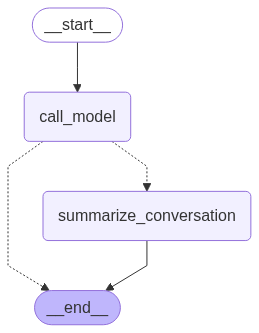

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from typing import cast
from langchain_core.runnables import RunnableConfig
import json

config: RunnableConfig = {"configurable": {"thread_id": "1"}}

In [9]:
for chunk in graph.stream(cast(State,{"messages": [HumanMessage(content="hi! I'm Lance")]}), config, stream_mode="updates"):
    print(chunk)

{'call_model': {'messages': AIMessage(content='Hi Lance! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': None, 'id': 'chatcmpl-ButFF1lA9c1FzXYnF9FId5OzsDlu5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--41579b2d-a7ec-4b06-8a1a-25e1c625d7eb-0', usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}


In [10]:
for chunk in graph.stream(cast(State,{"messages": [HumanMessage(content="tell me in one word who is Virat Kohli?")]}), config, stream_mode="updates"):
    chunk['call_model']["messages"].pretty_print()

================================== Ai Message ==================================

Cricketer.


In [ ]:
for event in graph.stream(cast(State,{"messages": [HumanMessage(content="for which team he plays?")]}), config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hi Lance! How can I assist you today?
================================ Human Message =================================

tell me in one word who is Virat Kohli?
================================== Ai Message ==================================

Cricketer.
================================ Human Message =================================

for which team he plays?
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hi Lance! How can I assist you today?
================================ Human Message =================================

tell me in one word who is Virat Kohli?
================================== Ai Message ==

We use astream events when you want contextual workflow events along with tokens—great for building rich UIs or logging/debugging.

In [12]:
config: RunnableConfig = {"configurable": {"thread_id": "2"}}
input_message = HumanMessage(content="Tell some of the best books to help me with my emotional intelligence.")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    metadata = event.get("metadata", {})
    node = metadata.get("langgraph_node", "")
    print(f"Node: {node}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: call_model. Type: on_chain_start. Name: call_model
Node: call_model. Type: on_chat_model_start. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model. Type: on_chat_model_stream. Name: ChatOpenAI
Node: call_model

The central point is that tokens from chat models within your graph have the on_chat_model_stream type.

In [ ]:
node_to_stream = 'chat_model'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

In [ ]:
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")